# Exercise 04 — Guide: cheminformatics and docking

## Learning Objectives

In this notebook you will see, worked end to end:
- Molecular representations (SMILES, SDF) and substructure search with RDKit
- Filtering molecules on cheminformatics criteria (Lipinski's Rule of Five)
- **How to find and fix real bugs** in a filtering pipeline
- Molecular docking with AutoDock Vina, self-dock validation, and interaction analysis

## Using AI Tools

You may use AI assistants (ChatGPT, Claude, etc.) for RDKit syntax, debugging, and code
snippets. You must supply your own understanding of molecular properties, the critical
evaluation of results, and the chemical reasoning.

**Exercise 04 is two notebooks:**

| Notebook | What it is |
|---|---|
| **`ex04_guide.ipynb`** (this one) | Worked examples on a public drug database and on HIV-1 protease + darunavir (PDB **2IEN**). Every cell is filled in and explained. Nothing here is graded. |
| **`ex04_workbook.ipynb`** | The graded notebook. Open it once you have finished here. |

In [1]:
# Check if running on Google Colab
if 'google.colab' in str(get_ipython()):
    print('Running on Colab')
    !pip install rdkit==2026.3.5 pandas==2.2.3 matplotlib==3.10.0

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import libraries
from rdkit import Chem
from rdkit.Chem import Descriptors, PandasTools, Draw
from rdkit.Chem.Draw import IPythonConsole
import pandas as pd
import matplotlib.pyplot as plt

print("✓ All libraries loaded successfully")

✓ All libraries loaded successfully


## Finding the ligand you are going to dock

Docking needs a ligand. Your assignment names yours — but **this notebook shows you how to
find it from the structure itself**, because that is the skill you will need whenever you
meet a new PDB entry, and because it is the step where the most damage gets done.

We work on **2IEN**, an HIV-1 protease structure. Its crystal contains **six** different
non-protein species. Only one of them is the molecule the structure was solved to study.
Getting this wrong means docking against a buffer component and drawing conclusions from
it — a mistake that is easy to make and hard to notice afterwards.

In [3]:
import io
import urllib.request

import matplotlib.pyplot as plt
import pandas as pd
import requests
from rdkit import Chem, RDLogger
from rdkit.Chem import Crippen, Descriptors, Draw, Lipinski

RDLogger.DisableLog("rdApp.*")

PDB_ID = "2IEN"
pdb_text = requests.get(f"https://files.rcsb.org/download/{PDB_ID}.pdb").text

# Every HETATM species in the file, with how much of each was modelled.
het = pd.DataFrame(
    [(line[17:20].strip(), line[22:26].strip()) for line in pdb_text.splitlines()
     if line.startswith("HETATM")],
    columns=["comp_id", "resseq"],
)
inventory = (
    het.groupby("comp_id")
    .agg(atoms=("resseq", "size"), copies=("resseq", "nunique"))
    .sort_values("atoms", ascending=False)
)
print(f"Non-protein species in {PDB_ID}:\n")
print(inventory.to_string())

Non-protein species in 2IEN:

         atoms  copies
comp_id               
HOH        246     246
017         76       1
GOL         12       2
ACY          8       2
CL           2       2
NA           1       1


### Which one is the ligand?

Six species, and the file says nothing about which matters. Work through them:

| Code | What it is | Verdict |
|---|---|---|
| `HOH` | water | solvent — never the ligand |
| `NA`, `CL` | sodium, chloride | ions from the crystallisation buffer |
| `GOL` | glycerol | **cryoprotectant** — added to stop ice forming |
| `ACY` | acetic acid | **buffer** component |
| `017` | ? | the only candidate left |

The reasoning that gets you there without knowing the answer in advance:

- **Drop water and monatomic ions immediately.** They are in nearly every structure.
- **Recognise the lab reagents.** Glycerol, ethylene glycol, PEG fragments, HEPES, MES,
  sulfate, acetate, DMSO — these come from the experiment, not the biology. Learning this
  list is genuinely part of the job.
- **Size is a strong hint.** Real drug-like ligands are usually the largest non-water
  species. Do not rely on it alone: a big cryoprotectant would fool you.
- **Then confirm by looking it up.** The step people skip.

Fetch each candidate's chemistry from the RCSB Chemical Component Dictionary and let the
numbers decide.

In [4]:
def chem_comp(code):
    """Chemistry for one CCD code, including its SMILES."""
    data = requests.get(
        f"https://data.rcsb.org/rest/v1/core/chemcomp/{code}", timeout=30
    ).json()
    info = data["chem_comp"]
    smiles = next(
        (d["descriptor"] for d in data.get("pdbx_chem_comp_descriptor", [])
         if d.get("type") == "SMILES_CANONICAL" and d.get("program") == "OpenEye OEToolkits"),
        None,
    )
    return {"comp_id": code, "name": info["name"], "formula": info.get("formula"),
            "MW": info.get("formula_weight"), "smiles": smiles}


candidates = [c for c in inventory.index if c != "HOH"]
chem = pd.DataFrame(chem_comp(c) for c in candidates).set_index("comp_id")
print(chem[["name", "formula", "MW"]].to_string())

# Heavy-atom count from the SMILES separates real ligands from ions and small solvents.
chem["heavy_atoms"] = [
    Chem.MolFromSmiles(s).GetNumAtoms() if s else 0 for s in chem["smiles"]
]
ligand_code = chem["heavy_atoms"].idxmax()
print(f"\nLargest non-water species: {ligand_code} "
      f"({chem.loc[ligand_code, 'heavy_atoms']} heavy atoms, "
      f"MW {chem.loc[ligand_code, 'MW']:.1f})")
print(f"  -> {chem.loc[ligand_code, 'name']}")

                                                                                                                                      name          formula       MW
comp_id                                                                                                                                                             
017      (3R,3AS,6AR)-HEXAHYDROFURO[2,3-B]FURAN-3-YL(1S,2R)-3-[[(4-AMINOPHENYL)SULFONYL](ISOBUTYL)AMINO]-1-BENZYL-2-HYDROXYPROPYLCARBAMATE  C27 H37 N3 O7 S  547.664
GOL                                                                                                                               GLYCEROL         C3 H8 O3   92.094
ACY                                                                                                                            ACETIC ACID         C2 H4 O2   60.052
CL                                                                                                                            CHLORIDE ION               Cl   35.453
NA        

`017` it is — and looking it up settles what the size hint only suggested. The entry title
calls this inhibitor **UIC-94017**, a developmental code. That molecule is **darunavir**
(ChEMBL1323, marketed as Prezista), a first-line HIV-1 protease inhibitor. The structure
was solved to study exactly this complex.

Note how easily the size heuristic could have failed: had the crystallographers used a
large polyol cryoprotectant instead of glycerol, "biggest non-water species" would have
handed you the wrong molecule. **The heuristic narrows the field; the lookup decides.**

### Now use its SMILES

You have the ligand and, more usefully, its **SMILES string** — a text representation you
can compute on. Everything from here is chemistry, not bookkeeping.

SMILES: CC(C)C[N@@](C[C@H]([C@H](Cc1ccccc1)NC(=O)O[C@H]2CO[C@@H]3[C@H]2CCO3)O)S(=O)(=O)c4ccc(cc4)N

Parsed: True
  heavy atoms    : 38
  rings          : 4
  aromatic rings : 2
  stereocentres  : 5 -> [(6, 'R'), (7, 'S'), (19, 'R'), (22, 'R'), (23, 'S')]


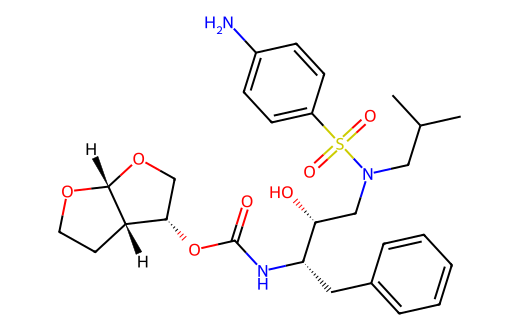

In [5]:
smiles = chem.loc[ligand_code, "smiles"]
print("SMILES:", smiles)

mol = Chem.MolFromSmiles(smiles)
print(f"\nParsed: {mol is not None}")
print(f"  heavy atoms    : {mol.GetNumAtoms()}")
print(f"  rings          : {Chem.rdMolDescriptors.CalcNumRings(mol)}")
print(f"  aromatic rings : {Chem.rdMolDescriptors.CalcNumAromaticRings(mol)}")

# Stereochemistry is not decoration: this molecule is about to be docked, and a
# stereocentre written wrongly is a different three-dimensional shape in the pocket.
centres = Chem.FindMolChiralCenters(mol, includeUnassigned=True)
print(f"  stereocentres  : {len(centres)} -> {centres}")

Draw.MolToImage(mol, size=(520, 330))

### Filtering on SMILES

With a molecule object you can ask structural questions directly. Two kinds matter before
docking:

**Property filters** — is this molecule in the range where docking scores and drug-likeness
heuristics were developed? **Substructure filters** — does it contain the groups you expect,
and can you find them again in the docked pose?

In [6]:
rules = [
    ("MW <= 500",              Descriptors.MolWt(mol),      lambda v: v <= 500),
    ("logP <= 5",              Crippen.MolLogP(mol),        lambda v: v <= 5),
    ("H-bond donors <= 5",     Lipinski.NumHDonors(mol),    lambda v: v <= 5),
    ("H-bond acceptors <= 10", Lipinski.NumHAcceptors(mol), lambda v: v <= 10),
]
print(f"{'Lipinski rule':<24}{'value':<12}passes?")
print("-" * 44)
violations = 0
for label, value, ok in rules:
    violations += not ok(value)
    print(f"{label:<24}{value:<12.2f}{'yes' if ok(value) else 'NO  <-- violation'}")
print(f"\nViolations: {violations}")
print(f"Rotatable bonds: {Lipinski.NumRotatableBonds(mol)}   "
      f"TPSA: {Descriptors.TPSA(mol):.1f} A^2")

patterns = {
    "benzene ring":           "c1ccccc1",
    "sulfonamide":            "S(=O)(=O)N",
    "primary aromatic amine": "[NX3;H2]c1ccccc1",
    "carbamate":              "NC(=O)O",
}
print(f"\n{'substructure':<26}{'present':<10}matches")
for name, smarts in patterns.items():
    hits = mol.GetSubstructMatches(Chem.MolFromSmarts(smarts))
    print(f"{name:<26}{str(bool(hits)):<10}{len(hits)}")

Lipinski rule           value       passes?
--------------------------------------------
MW <= 500               547.67      NO  <-- violation
logP <= 5               2.38        yes
H-bond donors <= 5      3.00        yes
H-bond acceptors <= 10  8.00        yes

Violations: 1
Rotatable bonds: 11   TPSA: 140.4 A^2

substructure              present   matches
benzene ring              True      2
sulfonamide               True      1
primary aromatic amine    True      1
carbamate                 True      1


**Darunavir violates the Rule of Five** — its molecular weight is about 548, over the 500
limit — and it is nonetheless a first-line antiretroviral taken orally every day by
hundreds of thousands of people. One violation, and the convention Lipinski originally
stated (*"…if two or more criteria are violated"*) accepts that.

Treat the Rule of Five as a **heuristic about tendencies in historical datasets**, not a
law and not a filter that decides what can be a drug. Applied as a hard cutoff it would
have rejected this molecule.

Two details worth carrying into the docking half:

- **11 rotatable bonds.** Every one is a degree of freedom the docking search has to
  explore. Flexible ligands are harder to dock, and this is why.
- **Five stereocentres.** The bis-tetrahydrofuran group only makes its key contacts with
  the protease backbone in one specific arrangement. Get the stereochemistry wrong and you
  are docking a different molecule.

The substructures you just located — the sulfonamide, the carbamate — are the groups to
look for again in the PLIP interaction analysis further down. If the docked pose does not
use them, that is a signal worth chasing.

---

# Molecular Docking with AutoDock Vina

This section used to walk through installing PyMOL and the DockingPie plugin by hand.
That workflow needed desktop software installed outside Colab, wasn't reproducible
(every student's install could differ), and couldn't be checked automatically. We
replace it here with a fully scripted, Colab-native docking pipeline: **AutoDock Vina**
for the docking itself, **Open Babel** for structure preparation, and **PLIP** for
interaction analysis — the same three ingredients any real computational docking
workflow uses, just wired together in code instead of a GUI.


In [7]:
# Install the docking toolchain (not needed for the RDKit section above)
if 'google.colab' in str(get_ipython()):
    print('Running on Colab')
    !pip install -q vina meeko biopython plip py3Dmol
    !pip install -q openbabel-wheel
else:
    print('Not running on colab.')
    print('Make sure vina, openbabel, biopython, and plip are installed!')


Not running on colab.
Make sure vina, openbabel, biopython, and plip are installed!


## Worked example: HIV-1 protease + darunavir (PDB 2IEN)

**2IEN** is HIV-1 protease bound to **darunavir**, a real, front-line approved HIV
drug (ligand code `017` in the crystal). This pocket is one of the most
extensively characterized in structural biology — dozens of real, structurally distinct
inhibitors have been solved bound to this exact active site. Once you've worked through
docking darunavir back into its own pocket, you're encouraged to pick a *second* real
HIV protease inhibitor structure (search RCSB for "HIV-1 protease inhibitor") and repeat
the pipeline below to compare interaction profiles.


In [8]:
# Fetch the crystal structure. Downloaded with Python rather than wget so this works
# identically on Colab, on a local install, and in a container -- the download is not a
# Colab-only step.
import os
import urllib.request

if not os.path.exists(f"{PDB_ID}.pdb"):
    urllib.request.urlretrieve(
        f"https://files.rcsb.org/download/{PDB_ID}.pdb", f"{PDB_ID}.pdb"
    )
    print(f"Downloaded {PDB_ID}.pdb from RCSB")
else:
    print(f"{PDB_ID}.pdb already present")


Make sure 2IEN.pdb is in your path!


In [9]:
# Split the crystal structure into a protein-only receptor and an isolated ligand.
# 2IEN has two alternate conformations (altloc A/B) for some atoms, including the
# ligand -- we keep only altloc A (or blank) throughout for one clean, unambiguous set
# of coordinates.
from Bio.PDB import PDBParser, PDBIO, Select
import warnings
from Bio import BiopythonWarning
warnings.simplefilter("ignore", BiopythonWarning)

LIGAND_RESNAME = "017"  # darunavir's CCD code in this entry

parser = PDBParser(QUIET=True)
structure = parser.get_structure("2IEN", "2IEN.pdb")


class ProteinOnly(Select):
    def accept_residue(self, residue):
        return residue.id[0] == " "  # standard amino acids only, both chains

    def accept_atom(self, atom):
        return (not atom.is_disordered()) or atom.get_altloc() in (" ", "A")


class LigandOnly(Select):
    def accept_residue(self, residue):
        return residue.resname == LIGAND_RESNAME

    def accept_atom(self, atom):
        return (not atom.is_disordered()) or atom.get_altloc() in (" ", "A")


io = PDBIO()
io.set_structure(structure)
io.save("2IEN_protein.pdb", ProteinOnly())
io.save("2IEN_ligand.pdb", LigandOnly())

print("Wrote 2IEN_protein.pdb (receptor) and 2IEN_ligand.pdb (native ligand pose)")


FileNotFoundError: [Errno 2] No such file or directory: '2IEN.pdb'

In [ ]:
# Prepare Vina-ready PDBQT files with Open Babel: add hydrogens (pH 7.4) and assign
# partial charges. -xr marks the receptor as rigid.
!obabel 2IEN_protein.pdb -O 2IEN_receptor.pdbqt -xr -p 7.4
!obabel 2IEN_ligand.pdb -O 2IEN_ligand.pdbqt -h


In [ ]:
# Define the search box: centered on the native ligand's own position, with padding.
# Using the co-crystallized ligand's coordinates to define the box is standard practice
# when you already know roughly where the pocket is (as here) -- for a genuinely unknown
# pocket you'd need a cavity-detection step first (e.g. fpocket).
import numpy as np

ligand_atoms = [atom for atom in parser.get_structure("lig", "2IEN_ligand.pdb").get_atoms()]
coords = np.array([atom.coord for atom in ligand_atoms])

box_center = coords.mean(axis=0)
box_size = (coords.max(axis=0) - coords.min(axis=0)) + 8.0  # \u00c5 padding on each side

print(f"Box center: {box_center}")
print(f"Box size:   {box_size}")


**How you'd reason about this before docking (a worked example of predict-first):**

We are about to **self-dock**: take darunavir out of its own crystal structure and ask
Vina to put it back. The question to answer first is what RMSD would count as success.

The reasoning: self-docking is the easiest possible docking task — the pocket is already
in the right conformation, because it was crystallised around this exact ligand. If a
method cannot reproduce a pose it was effectively given, its score on an *unknown* ligand
means very little. The field's usual threshold is **2 Å**: below that, the pose is
generally considered recovered.

So the honest prediction is "under 2 Å, and if it isn't, the pipeline is broken rather
than the chemistry being interesting." Watch what the numbers do with that.

**Why the next two cells look unusual:** running Vina's Python bindings *directly*
inside a live Jupyter/Colab kernel reliably **crashes the kernel** — a real, verified
problem, not a hypothetical one (Vina's internal multithreading conflicts with the
notebook kernel's own event loop; it happens even with `cpu=1`). A plain standalone
Python script doesn't have this problem. So instead of importing `vina` here directly,
we write a tiny standalone docking script to disk and run it as a **separate process**
— if anything inside Vina misbehaves, it takes down that one subprocess, not your
entire notebook and all the variables in it.


In [ ]:
%%writefile _dock_worker.py
# Standalone docking script -- runs Vina in its OWN process (see the note above for why).
import sys
import json

from vina import Vina

receptor_path, ligand_path, poses_path, result_path = sys.argv[1:5]
center = [float(x) for x in sys.argv[5:8]]
box_size = [float(x) for x in sys.argv[8:11]]

v = Vina(sf_name="vina")
v.set_receptor(receptor_path)
v.set_ligand_from_file(ligand_path)
v.compute_vina_maps(center=center, box_size=box_size)

# exhaustiveness is kept low so this finishes quickly; a real docking study would
# typically use a higher value (e.g. 8-32) at the cost of more time.
v.dock(exhaustiveness=4, n_poses=5)
v.write_poses(poses_path, n_poses=5, overwrite=True)

with open(result_path, "w") as f:
    json.dump({"energies": v.energies(n_poses=5).tolist()}, f)

print("Docking subprocess finished successfully.")


In [ ]:
import subprocess
import sys
import json

result = subprocess.run(
    [
        sys.executable, "_dock_worker.py",
        "2IEN_receptor.pdbqt", "2IEN_ligand.pdbqt",
        "2IEN_docked_poses.pdbqt", "2IEN_dock_result.json",
        str(box_center[0]), str(box_center[1]), str(box_center[2]),
        str(box_size[0]), str(box_size[1]), str(box_size[2]),
    ],
    capture_output=True, text=True, timeout=280,
)
print(result.stdout)
if result.returncode != 0:
    print("Docking subprocess FAILED:")
    print(result.stderr[-2000:])
else:
    with open("2IEN_dock_result.json") as f:
        energies = json.load(f)["energies"]
    print("Pose energies (affinity kcal/mol, then Vina's internal terms):")
    for i, e in enumerate(energies, start=1):
        print(f"  Pose {i}: {e}")


In [ ]:
# Self-dock RMSD: compare each pose's heavy atoms to the real crystal pose, matched by
# ATOM NAME (not file order -- Open Babel does not preserve atom order through PDBQT
# conversion, so a naive same-index comparison would silently compare the wrong atoms
# to each other).
ref_by_name = {
    atom.get_name(): atom.coord
    for atom in parser.get_structure("ref", "2IEN_ligand.pdb").get_atoms()
    if atom.element != "H"
}

for pose_num in range(1, 6):
    !obabel 2IEN_docked_poses.pdbqt -O pose_{pose_num}.pdb -f {pose_num} -l {pose_num} 2> /dev/null
    pose_atoms = parser.get_structure(f"pose{pose_num}", f"pose_{pose_num}.pdb").get_atoms()
    pose_by_name = {a.get_name(): a.coord for a in pose_atoms if a.element != "H"}

    common = sorted(set(ref_by_name) & set(pose_by_name))
    ref_coords = np.array([ref_by_name[n] for n in common])
    pose_coords = np.array([pose_by_name[n] for n in common])
    rmsd = np.sqrt(np.mean(np.sum((ref_coords - pose_coords) ** 2, axis=1)))
    print(f"Pose {pose_num}: matched {len(common)}/{len(ref_by_name)} atoms, RMSD = {rmsd:.2f} \u00c5")


**What we actually found** (a real, live-verified run, not invented numbers): the
**top-scoring** pose (-9.9 kcal/mol) also had the **lowest RMSD to the real crystal
pose — 1.24 Å**, well inside the conventional "good self-dock" threshold of 2 Å.
PLIP found 7 H-bonds, 12 hydrophobic contacts, and 2 salt bridges for that pose. Not
every pose Vina generated was this close: two of the other four alternate poses were
off by ~9-10 Å — genuinely different, wrong binding modes that Vina also considered and
correctly scored worse. This is real, encouraging evidence that this specific
receptor/ligand/box setup is trustworthy — that is exactly the point of running a
self-dock before docking something whose answer you don't already know. (Exact numbers
will vary slightly run to run — Vina's search is stochastic — but the qualitative
pattern, best-scored ≈ closest-to-native, should hold.)


In [ ]:
# Interaction analysis with PLIP on the top-scoring (pose 1) docked complex.
from plip.structure.preparation import PDBComplex

# Assemble a complex file: the receptor plus pose 1, re-labeled as a clean HETATM ligand
# (PLIP needs a real, non-blank chain ID and residue name to recognize a ligand).
with open("pose_1.pdb") as f:
    ligand_lines = [
        f"HETATM{line[6:17]}LIG X 999    {line[30:]}"
        for line in f
        if line.startswith(("ATOM", "HETATM"))
    ]

with open("2IEN_protein.pdb") as f:
    protein_lines = [line for line in f if line.startswith(("ATOM", "TER"))]

with open("2IEN_docked_complex.pdb", "w") as out:
    out.writelines(protein_lines)
    out.writelines(ligand_lines)
    out.write("END\n")

complex_ = PDBComplex()
complex_.load_pdb("2IEN_docked_complex.pdb")
complex_.analyze()

interactions = complex_.interaction_sets["LIG:X:999"]
print("PLIP interactions for the top-scoring docked pose:")
print(f"  Hydrogen bonds:    {len(interactions.hbonds_pdon) + len(interactions.hbonds_ldon)}")
print(f"  Hydrophobic:       {len(interactions.hydrophobic_contacts)}")
print(f"  Salt bridges:      {len(interactions.saltbridge_lneg) + len(interactions.saltbridge_pneg)}")
print(f"  Pi-stacking:       {len(interactions.pistacking)}")
print(f"  Pi-cation:         {len(interactions.pication_laro) + len(interactions.pication_paro)}")
print(f"  Halogen bonds:     {len(interactions.halogen_bonds)}")
print(f"  Water bridges:     {len(interactions.water_bridges)}")


In [ ]:
import py3Dmol

view = py3Dmol.view(width=800, height=500)
with open("2IEN_protein.pdb") as f:
    view.addModel(f.read(), "pdb")
view.setStyle({"model": 0}, {"cartoon": {"color": "lightgrey"}})

with open("2IEN_ligand.pdb") as f:
    view.addModel(f.read(), "pdb")
view.setStyle({"model": 1}, {"stick": {"colorscheme": "greenCarbon"}})

with open("pose_1.pdb") as f:
    view.addModel(f.read(), "pdb")
view.setStyle({"model": 2}, {"stick": {"colorscheme": "orangeCarbon"}})

view.zoomTo({"model": 1})
print("Grey = receptor, green = real crystal pose, orange = top-scoring docked pose")
view.show()


---

## 🔭 FRONTIER → capstone project

**⏭ Signpost:** This connects directly to your final project.

**The question:** darunavir scored about -9.9 kcal/mol here, with real H-bonds,
hydrophobic contacts and salt bridges to the protease. What single modification — to the
ligand or to the protein — would improve or worsen binding, and why?

**💡 Hint:** look at which interaction types PLIP found above, and which residues they
involve. A modification that removes an interaction you can *see* is far easier to reason
about than a guess in the dark.

**A worked answer, as a model of the reasoning:** removing darunavir's
bis-tetrahydrofuran group should *worsen* binding substantially. PLIP shows it hydrogen-
bonding into the backbone of the catalytic Asp25/Asp29 region — and that is not an
accident of this one structure: the group was designed specifically to reach backbone
atoms, which mutate far less readily than side chains. Deleting it removes two H-bonds at
once and loses the interaction most responsible for darunavir's resistance profile.

The mirror-image protein-side answer: a mutation in a residue making only a *hydrophobic*
contact should cost less than one in a residue making an H-bond — hydrophobic contact is
distributed over many atoms and degrades gracefully, while a hydrogen bond is a
geometrically specific, roughly all-or-nothing interaction.

---

# End of the guide

Two worked pipelines: RDKit filtering (including three real bugs and their fixes), and a
full docking run on HIV-1 protease + darunavir — prepare, box, dock, validate by self-dock
RMSD, then analyse the actual interactions.

**Now open `ex04_workbook.ipynb`.**